In [27]:
import networkx as nx
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import itertools
from infomap import Infomap
import sys

BASE_DIR = Path.cwd().parent
sys.path.insert(0, str(BASE_DIR))
graph = nx.read_gexf(BASE_DIR / "data" / "processed" / "world_trade_network_petrol_2024.gexf")

%load_ext autoreload
%autoreload 2

from src.graph_map_visualization import visualize_map_graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1) The Algorithm of Louvain:

In [14]:
# 1.1) Calculate the communities detected by Louvain and print its length: 
coms_louvain = list(nx.community.louvain_communities(graph, seed=42, weight='weight'))
print(f'{len(coms_louvain)} Louvain communities detected')

6 Louvain communities detected


In [15]:
# 1.2) Calculate the modularity of this partition (to see how decent it is): 
louvain_mod = nx.community.modularity(graph, coms_louvain, weight='weight')
print(f'Modularity = {louvain_mod}') # Decent modularity (bigger than 0.3).

Modularity = 0.39435707534547565


/tmp/ipykernel_17678/1426257228.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pallette = plt.cm.get_cmap('tab20', max(dict_louvain.values()) + 1)


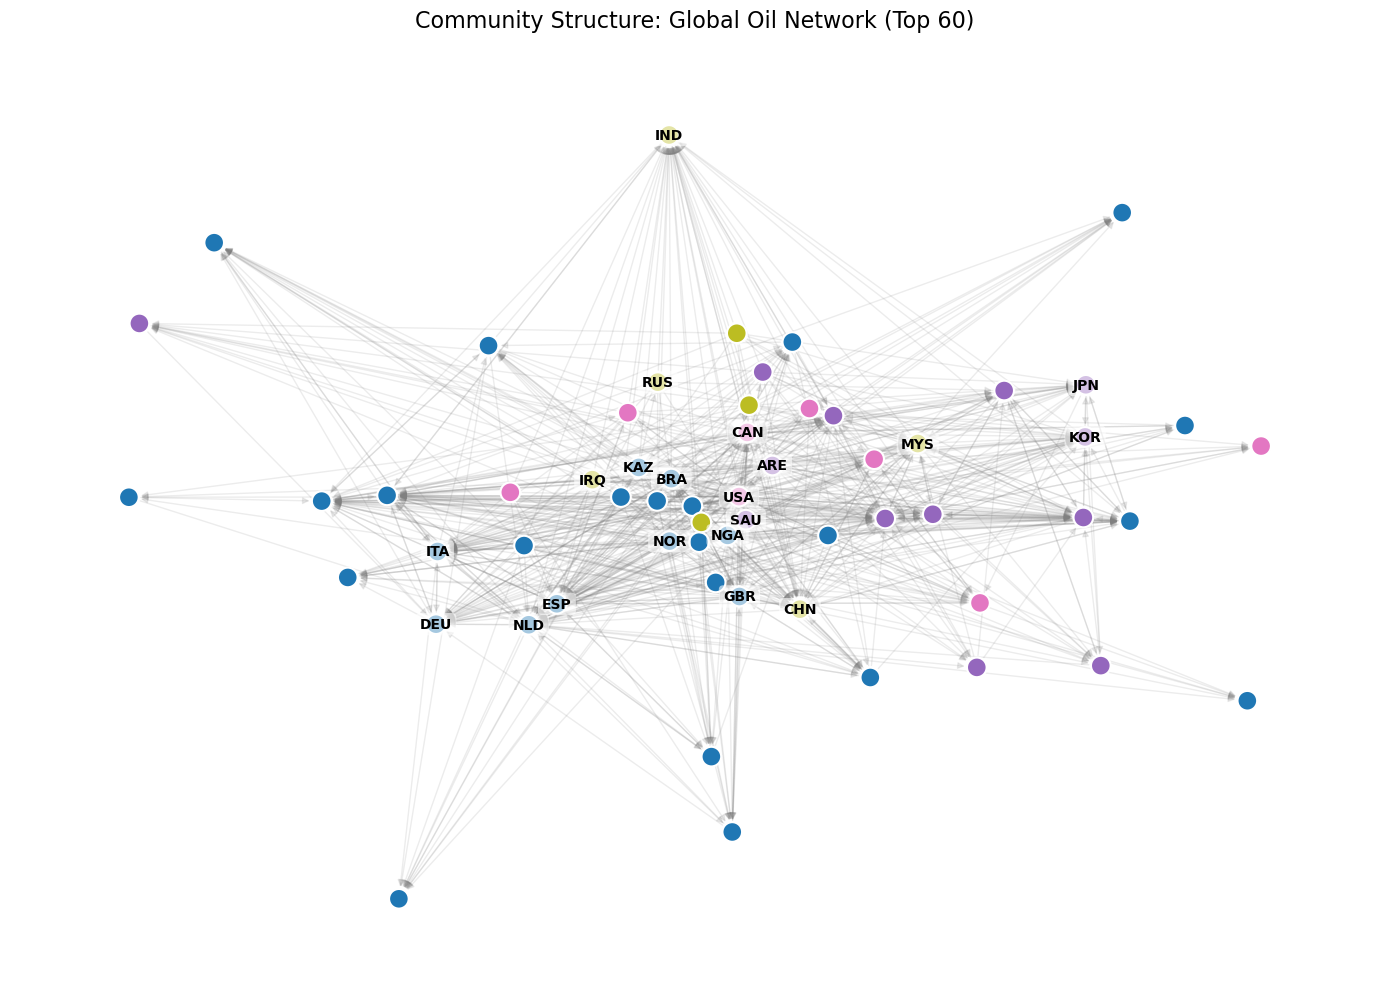

In [16]:
# 1.3) Visualize the graph with its calculated communities: 

# Filter the number of nodes in order to prevent saturation in the visualization: 
num_nodes = 60

degrees = dict(graph.degree(weight='weight'))
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:num_nodes]
filtered_graph = graph.subgraph(top_nodes)

# Create the respective dictionary for the communities calculated:
dict_louvain = {}
for i, com in enumerate(coms_louvain):
    for nodo in com:
        dict_louvain[nodo] = i

# Set colors for visualization: 
pallette = plt.cm.get_cmap('tab20', max(dict_louvain.values()) + 1)
node_colors = [pallette(dict_louvain[node]) for node in filtered_graph.nodes()]

# Adjust the sizes of nodes in terms of its degrees: 
parameter_size = 100000
node_sizes = [degrees[node] / parameter_size for node in filtered_graph.nodes()]

# Instead of using the weight directly, we shall create a temporary atribute
# so that the layout isn't so agressive:
for u, v, d in filtered_graph.edges(data=True):
    filtered_graph[u][v]['layout_weight'] = np.log1p(d['weight']) # log(1 + weight).

# Set the position on nodes using "spring_layout":
pos = nx.spring_layout(filtered_graph, weight='layout_weight', seed=42, k=1.5, iterations=50)

# Paint the graph: 
num_labels = 20
node_size = 200

plt.figure(figsize=(14, 10))
plt.title(f"Community Structure: Global Oil Network (Top {num_nodes})", fontsize=16, pad=20)

nx.draw_networkx_edges(filtered_graph, pos, alpha=0.15, edge_color='gray', arrows=True)
nx.draw_networkx_nodes(filtered_graph, pos, node_color=node_colors, 
                       node_size=node_size, edgecolors='white', linewidths=1.5)

top_labels = {n: n for n in sorted(top_nodes, key=degrees.get, reverse=True)[:num_labels]}
nx.draw_networkx_labels(filtered_graph, pos, labels=top_labels, font_size=10, 
                        font_weight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6, edgecolor='none'))

plt.axis('off')
plt.tight_layout()
plt.show()

In [28]:
# 1.4) Visualize the communities-graph with a map-format, using
# the respective "visualize_map_graph" in src: 
visualize_map_graph(
    input_filename="world_trade_network_petrol_2024.gexf",
    threshold=500000,
    title="Geopolitical Oil Communities 2024 (Louvain)",
    communities=dict_louvain, 
    min_size=40
)

/home/martin_kugler/Escritorio/proyectos_universidad/Social-Computing-Analysis/src/graph_map_visualization.py:37: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  coords_dict = df_coords.set_index('ISO3')[['LAT', 'LONG']].T.to_dict('list')


### 2) Algorithom of Girvan-Newman: 

In [ ]:
# 2.1) Calculate the communities detected by Grivan-Newman and print its length and modularity: 

# Create the attribute "distance":
for u, v, d in graph.edges(data=True):
    # We add a minuscule value (1e-6) to avoid divisions by zero in case any weight is 0:
    graph[u][v]['distance'] = 1 / (d['weight'] + 1e-6)

# We define a function that tells GN how to calculate the weight of the edges:
def heaviest_edge_betweenness(g):
    centrality =  nx.edge_betweenness_centrality(g, weight='distance')
    return max(centrality, key=centrality.get)

gen_gn = nx.community.girvan_newman(graph, most_valuable_edge=heaviest_edge_betweenness)

# Evaluate the first n divisions and select the one with the higher modularity: 
divisions = 20

gn_mod = -1.0
best_partition_gn = None

for partition in itertools.islice(gen_gn, divisions):
    mod = nx.community.modularity(graph, partition, weight='weight')
    
    if mod > gn_mod:
        gn_mod = mod
        best_partition_gn = partition

print(f'{len(best_partition_gn)} Girvan-Newman communities detected')
print(f'Modularity = {gn_mod}') # Dreadful modularity. 

### 3) InfoMap:

In [29]:
# 3.1) Calculate the communities detected by InfoMap and print its length: 

# InfoMap expects the nodes as numbers: 
node_names = list(graph.nodes())
map_id = {name: i for i, name in enumerate(node_names)}

# Initialize the InfoMap object: 
im = Infomap(silent=True, directed=True, two_level=True)

# Add the respective edges:
for u, v, d in graph.edges(data=True):
    im.add_link(map_id[u], map_id[v], d['weight'])

# Execute the algorithm: 
im.run()

# Extract the communities as a dictionary iterating the tree given by InfoMap: 
dict_coms_im = {}
for node in im.tree:

    if node.is_leaf:
        mod_id = node.module_id

        # Each country (iso) must be included in its community:
        if mod_id not in dict_coms_im:
            dict_coms_im[mod_id] = set()

        iso = node_names[node.node_id] 
        dict_coms_im[node.module_id].add(iso)

coms_im = dict_coms_im.values()

print(f'{im.num_top_modules} InfoMap communities detected')

23 InfoMap communities detected


In [30]:
# 3.2) Calculate the modularity of this partition: 
im_mod = nx.community.modularity(graph, coms_im, weight='weight')
print(f'Modularity = {im_mod}') # Decent modularity (bigger than 0.3).

Modularity = 0.2499612260058034


/tmp/ipykernel_17678/2609552454.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pallette = plt.cm.get_cmap('tab20', max(dict_im.values()) + 1)


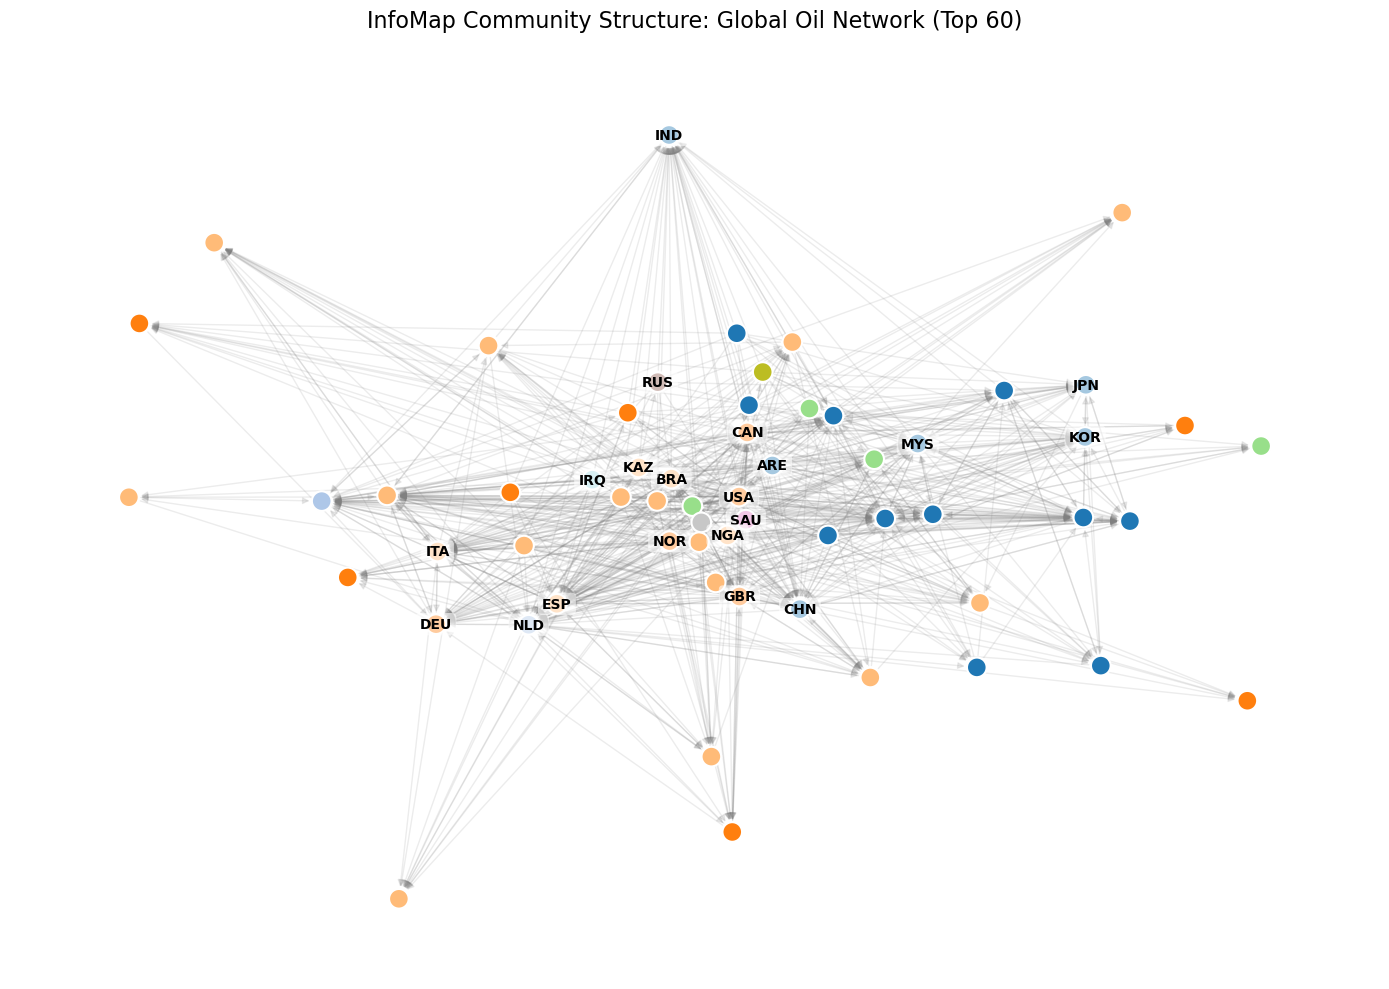

In [31]:
# 3.3) Visualize the graph with its calculated communities: 

# Filter the number of nodes in order to prevent saturation in the visualization: 
num_nodes = 60

degrees = dict(graph.degree(weight='weight'))
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:num_nodes]
filtered_graph = graph.subgraph(top_nodes)

# Change the format into a dictionary for visualization: 
dict_im = {}
for i, com in enumerate(coms_im):
    for node in com:
        dict_im[node] = i

# Set colors for visualization: 
pallette = plt.cm.get_cmap('tab20', max(dict_im.values()) + 1)
node_colors = [pallette(dict_im[node]) for node in filtered_graph.nodes()]

# Adjust the sizes of nodes in terms of its degrees: 
parameter_size = 100000

node_sizes = [degrees[node] / parameter_size for node in filtered_graph.nodes()]

# Instead of using the weight directly, we shall create a temporary atribute:
for u, v, d in filtered_graph.edges(data=True):
    filtered_graph[u][v]['layout_weight'] = np.log1p(d['weight'])

# Set the position on nodes using "spring_layout":
pos = nx.spring_layout(filtered_graph, weight='layout_weight', seed=42, k=1.5, iterations=50)

# Paint the graph: 
num_labels = 20
node_size = 200 

plt.figure(figsize=(14, 10))
plt.title(f"InfoMap Community Structure: Global Oil Network (Top {num_nodes})", fontsize=16, pad=20)

nx.draw_networkx_edges(filtered_graph, pos, alpha=0.15, edge_color='gray', arrows=True)
nx.draw_networkx_nodes(filtered_graph, pos, node_color=node_colors, 
                       node_size=node_size, edgecolors='white', linewidths=1.5)

top_labels = {n: n for n in sorted(top_nodes, key=degrees.get, reverse=True)[:num_labels]}
nx.draw_networkx_labels(filtered_graph, pos, labels=top_labels, font_size=10, 
                        font_weight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6, edgecolor='none'))

plt.axis('off')
plt.tight_layout()
plt.show()

In [32]:
# 3.4) Visualize the communities-graph with a map-format, using
# the respective "visualize_map_graph" in src: 
visualize_map_graph(
    input_filename="world_trade_network_petrol_2024.gexf",
    threshold=500000,
    title="Geopolitical Oil Communities 2024 (Louvain)",
    communities=dict_im, 
    min_size=40
)

/home/martin_kugler/Escritorio/proyectos_universidad/Social-Computing-Analysis/src/graph_map_visualization.py:37: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  coords_dict = df_coords.set_index('ISO3')[['LAT', 'LONG']].T.to_dict('list')
